<a href="https://colab.research.google.com/github/Haniya-Imran/ML-Algorithms-Projects/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Heart Disease Prediction Project**

# **Project Overview:**
This project aims to predict heart disease using various patient attributes. It involves data loading, exploratory data analysis, preprocessing, model training, and evaluation.

## **Contents:**
* Import Libraries
* Load Dataset
* Dataset Overview
* Exploratory Data Analysis (EDA)
* Data Preprocessing
* Feature Scaling
* Train-Test Split
* Model Training
* Model Evaluation
* Hyperparameter Tuning
* Pipeline
* Final Output
* Conclusion

### **Import Libraries:**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

### **Dataset load:**

In [ ]:
df = pd.read_csv('/content/heart.csv')
display(df)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


### **Dataset Overview:**

In [ ]:
display(df.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
display(df.tail())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [ ]:
display(df.shape)

(1025, 14)

In [ ]:
display(df.columns.tolist())

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'target']

In [ ]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


None

In [ ]:
display(df.describe())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
display(df.dtypes)

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [ ]:
display(df.isnull().sum())

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
display(df.duplicated().sum())

np.int64(723)

### **Data Cleaning:**

In [ ]:
df.drop_duplicates(inplace=True)
display(df.shape)

(302, 14)

In [ ]:
# Identify categorical columns to convert to 'category' dtype
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']
for col in categorical_cols:
    df[col] = df[col].astype('category')

display(df.dtypes)

,0
age,int64
sex,category
cp,category
trestbps,int64
chol,int64
fbs,category
restecg,category
thalach,int64
exang,category
oldpeak,float64


### **Outliers Section:**

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns

outlier_counts = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = outliers.shape[0]

display(pd.Series(outlier_counts, name='Outlier Count'))

,Outlier Count
age,0
trestbps,9
chol,5
thalach,1
oldpeak,5


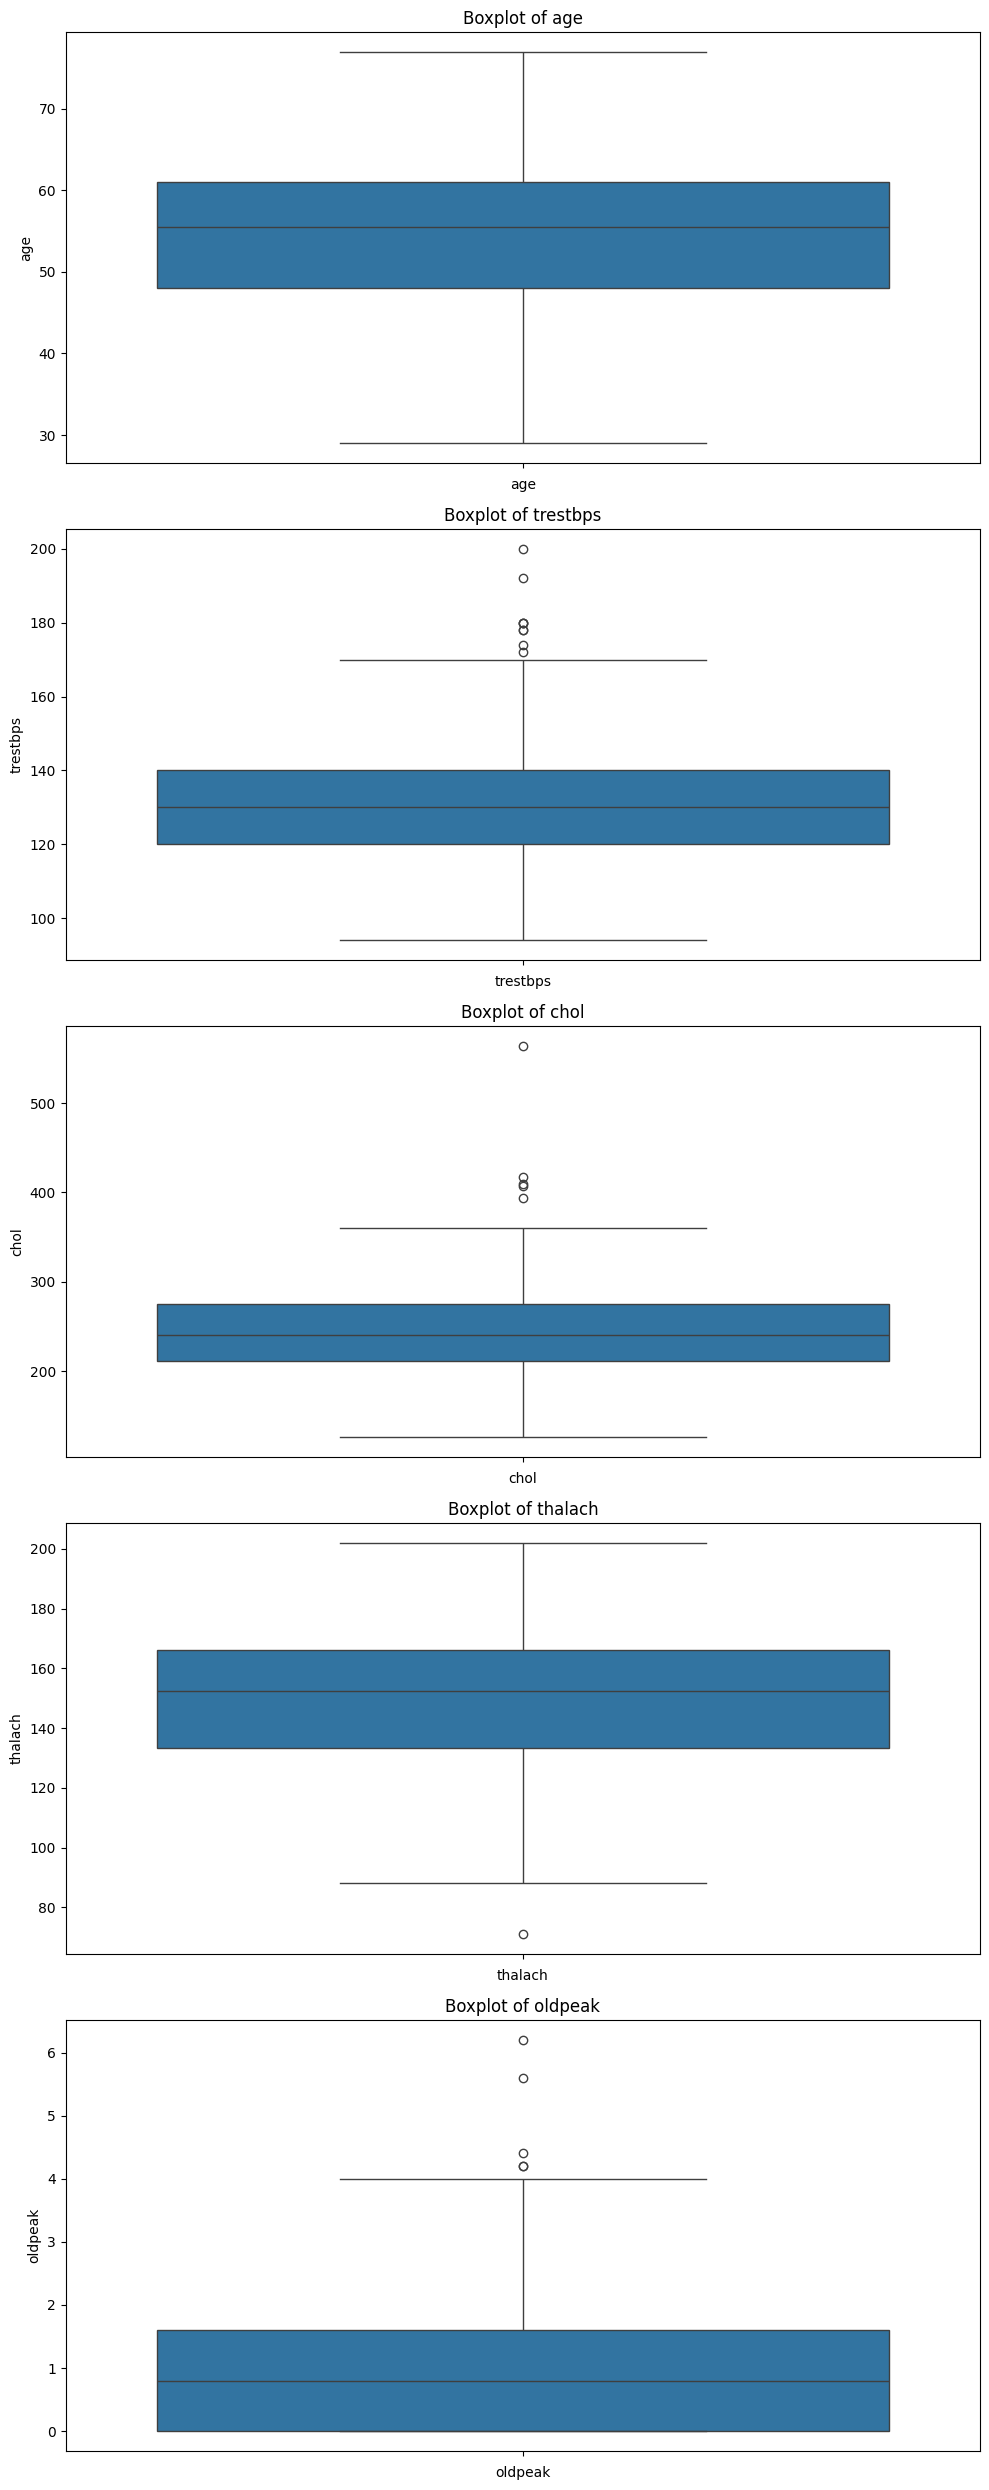

In [ ]:
num_cols = len(numerical_cols)
fig, axes = plt.subplots(nrows=num_cols, ncols=1, figsize=(10, 5 * num_cols))

# Adjust for single subplot case
if num_cols == 1:
    axes = [axes]

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

These boxplots show the distribution of numerical features and highlight potential outliers before capping.

In [ ]:
df_capped = df.copy()

for col in numerical_cols:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)

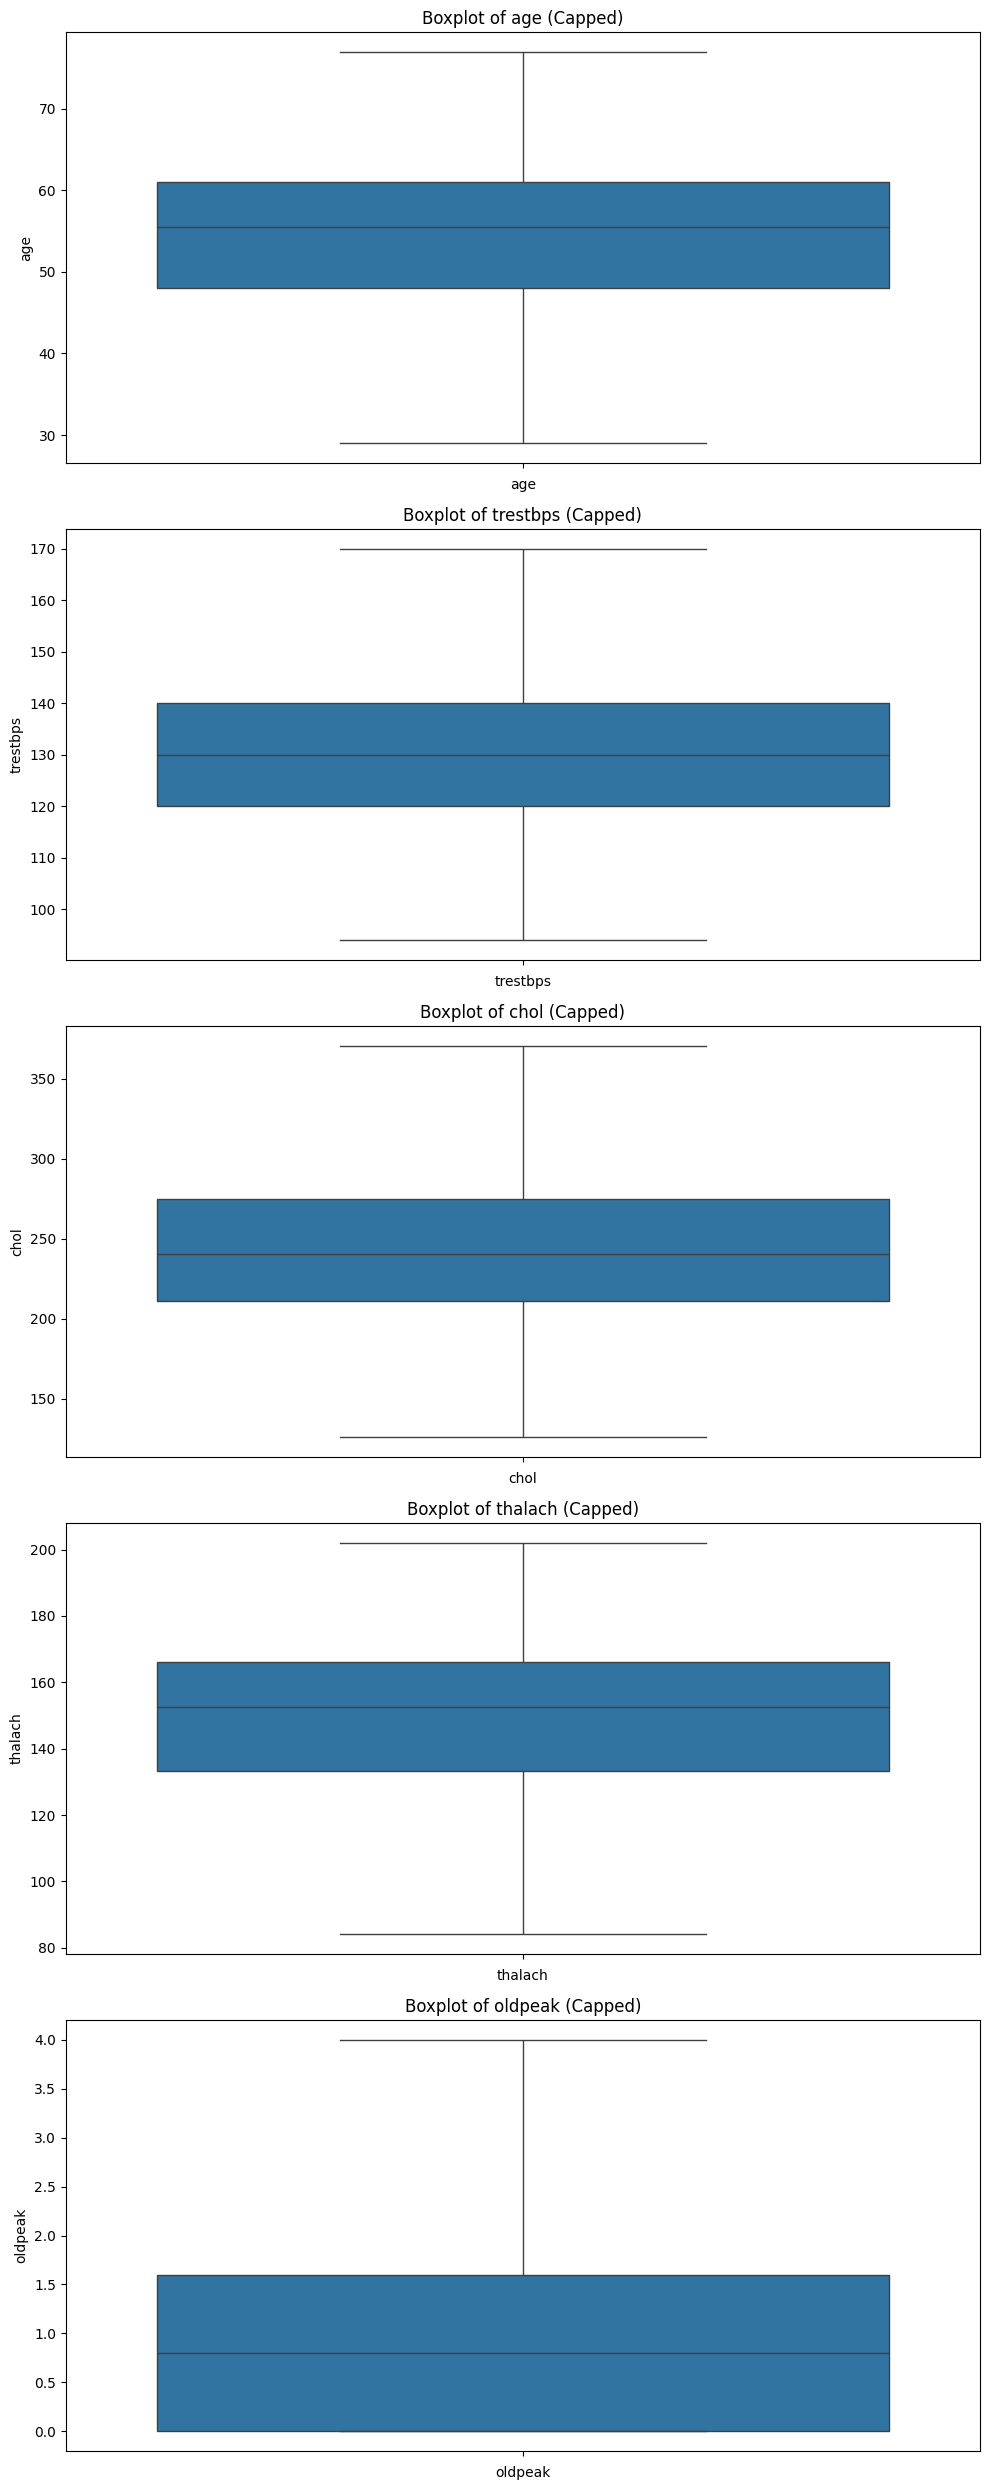

In [ ]:
num_cols = len(numerical_cols)
fig, axes = plt.subplots(nrows=num_cols, ncols=1, figsize=(10, 5 * num_cols))

# Adjust for single subplot case
if num_cols == 1:
    axes = [axes]

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df_capped[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col} (Capped)')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

These boxplots show the distribution of numerical features after capping, demonstrating the handling of outliers.

### **Exploratory Data Analysis:**

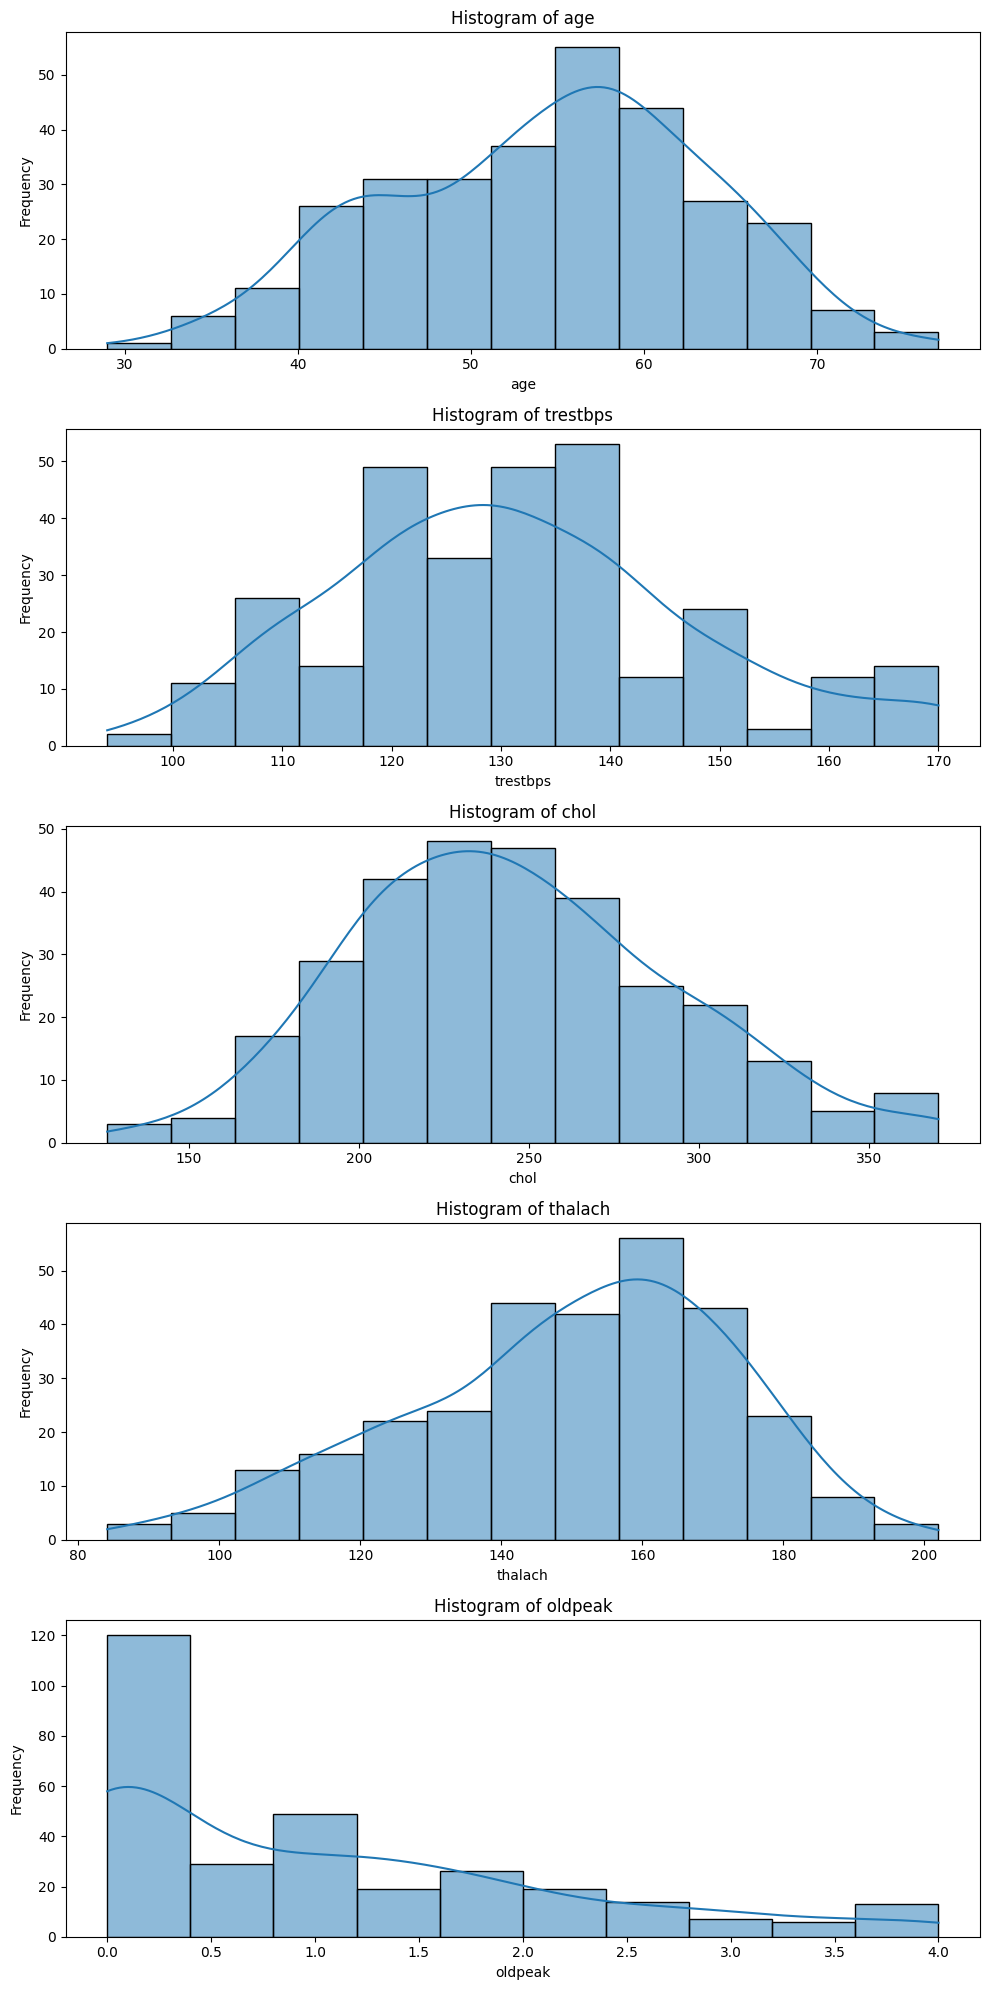

In [ ]:
df_numeric = df_capped.select_dtypes(include=np.number)
num_cols = len(df_numeric.columns)

fig, axes = plt.subplots(nrows=num_cols, ncols=1, figsize=(10, 4 * num_cols))

if num_cols == 1:
    axes = [axes]

for i, col in enumerate(df_numeric.columns):
    sns.histplot(df_numeric[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

These histograms visualize the distribution of each numerical feature, showing their frequency and spread.

In [ ]:
# Display the value counts for the 'target' variable
display(df_capped['target'].value_counts())

,count
target,
1,164
0,138


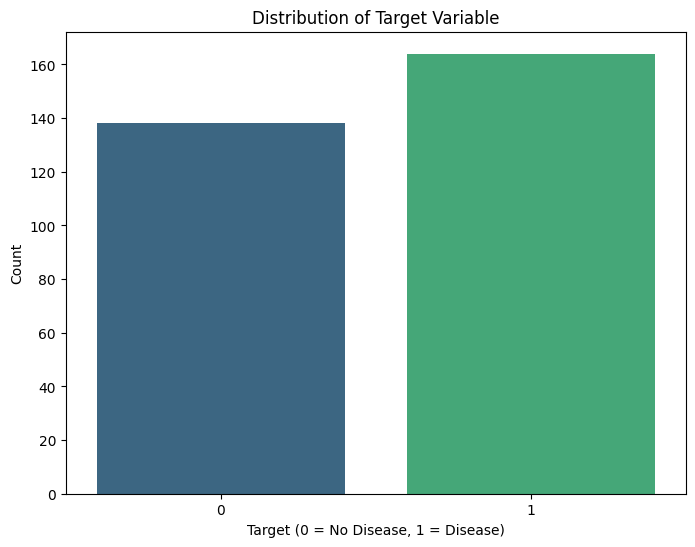

In [ ]:
# Create a countplot for the 'target' variable
plt.figure(figsize=(8, 6))
sns.countplot(x='target', data=df_capped, palette='viridis', hue='target', legend=False)
plt.title('Distribution of Target Variable')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')
plt.show()

This countplot illustrates the balance of the target variable, showing the number of patients with and without heart disease.

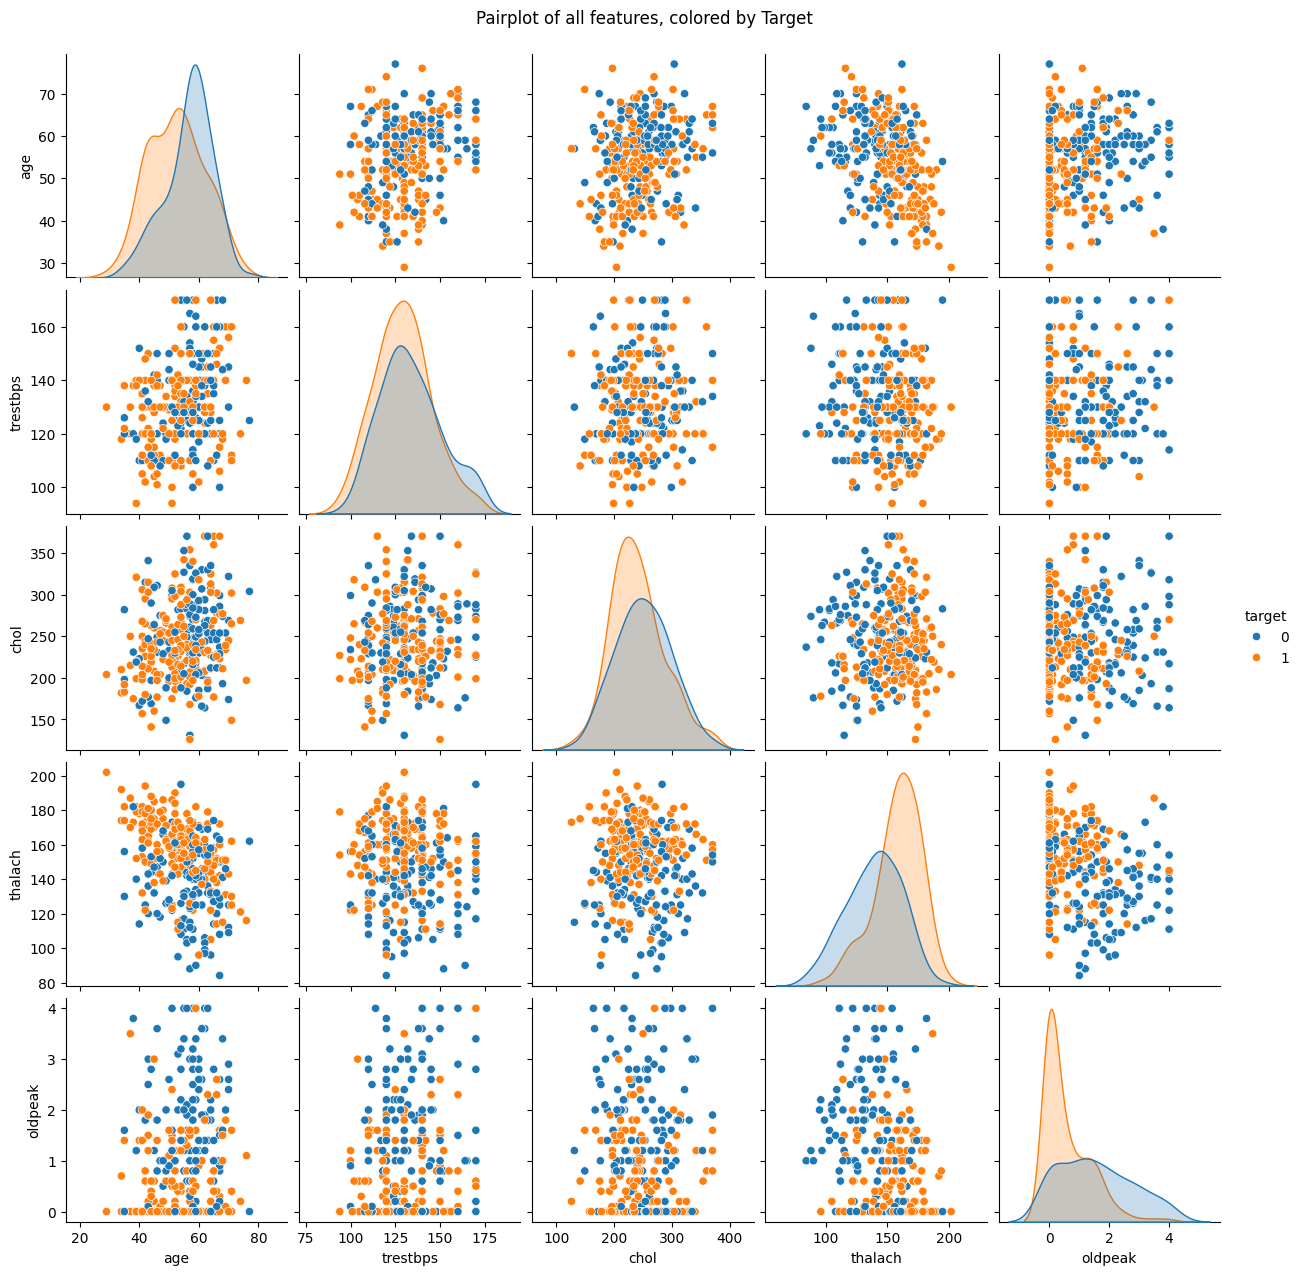

In [ ]:
fig = sns.pairplot(df_capped, hue='target')
plt.suptitle('Pairplot of all features, colored by Target', y=1.02)
plt.show()

This pairplot helps visualize relationships between all features, colored by the target variable to observe separation.

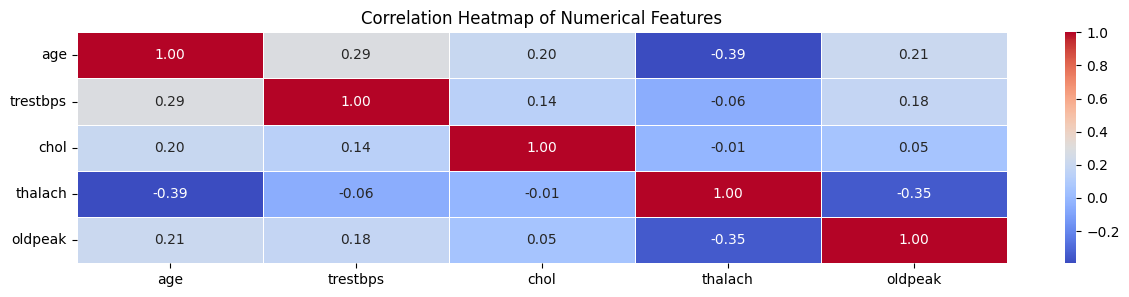

In [ ]:
plt.figure(figsize=(15 , 3))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

This heatmap shows the correlation matrix of numerical features, indicating the strength and direction of relationships between them.

### **Feature Engineering:**

In [ ]:
# Identify categorical columns (excluding the 'target') for one-hot encoding.
# The 'target' column is already binary (0/1) and suitable for direct use as a target variable.
categorical_features_for_ohe = df_capped.select_dtypes(include='category').columns.drop('target', errors='ignore')

# Apply one-hot encoding to the identified categorical features
df_encoded = pd.get_dummies(df_capped, columns=categorical_features_for_ohe, drop_first=True)

### **Data Preprocessing:**

In [ ]:
# Separate the features (X) from the target variable (y)
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

# Display the shapes of X and y to confirm the split
display(X.shape)
display(y.shape)

(302, 22)

(302,)

### **Feature Selection:**

In [ ]:
# For this initial phase, all available features in X are selected for model training.
# If specific feature selection methods (e.g., Recursive Feature Elimination, SelectKBest) were required,
# they would be implemented here based on predefined criteria.

# Display the columns of X to show the selected features
display(X.columns.tolist())

['age',
 'trestbps',
 'chol',
 'thalach',
 'oldpeak',
 'sex_1',
 'cp_1',
 'cp_2',
 'cp_3',
 'fbs_1',
 'restecg_1',
 'restecg_2',
 'exang_1',
 'slope_1',
 'slope_2',
 'ca_1',
 'ca_2',
 'ca_3',
 'ca_4',
 'thal_1',
 'thal_2',
 'thal_3']

### **Train-Test Split:**

In [ ]:
# Split the dataset into training and testing sets.
# 80% of the data will be used for training, and 20% for testing.
# A 'random_state' is set for reproducibility.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the resulting datasets
display(X_train.shape)
display(X_test.shape)
display(y_train.shape)
display(y_test.shape)

(241, 22)

(61, 22)

(241,)

(61,)

### **Feature Scaling:**

In [ ]:
# Initialize the StandardScaler.
scaler = StandardScaler()

# Identify the original continuous numerical columns to be scaled.
# One-hot encoded binary columns generally do not require scaling.
original_numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Apply scaling to the numerical features in the training set.
# The scaler is fitted only on the training data to prevent data leakage.
X_train[original_numerical_cols] = scaler.fit_transform(X_train[original_numerical_cols])

# Apply scaling to the numerical features in the test set using the same fitted scaler.
X_test[original_numerical_cols] = scaler.transform(X_test[original_numerical_cols])

### **Model Training:**

In [ ]:
# Initialize the SVC model with probability=True for prediction probabilities
# A random_state is set for reproducibility.
svm_classifier = SVC(random_state=42, probability=True)

In [ ]:
# Train the SVM Classifier using the scaled training data
svm_classifier.fit(X_train, y_train)

SVC(probability=True, random_state=42)

In [ ]:
# Make predictions on the scaled test data
y_pred = svm_classifier.predict(X_test)

In [ ]:
# Get prediction probabilities for the positive class (class 1)
y_pred_proba = svm_classifier.predict_proba(X_test)[:, 1]

### **Model Evaluation:**

In [ ]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

In [ ]:
# Display the metrics
display(f"Accuracy: {accuracy:.4f}")
display(f"Precision: {precision:.4f}")
display(f"Recall: {recall:.4f}")
display(f"F1 Score: {f1:.4f}")
display(f"AUC Score: {roc_auc:.4f}")

'Accuracy: 0.7869'

'Precision: 0.7353'

'Recall: 0.8621'

'F1 Score: 0.7937'

'AUC Score: 0.8551'

In [ ]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[23  9]
 [ 4 25]]


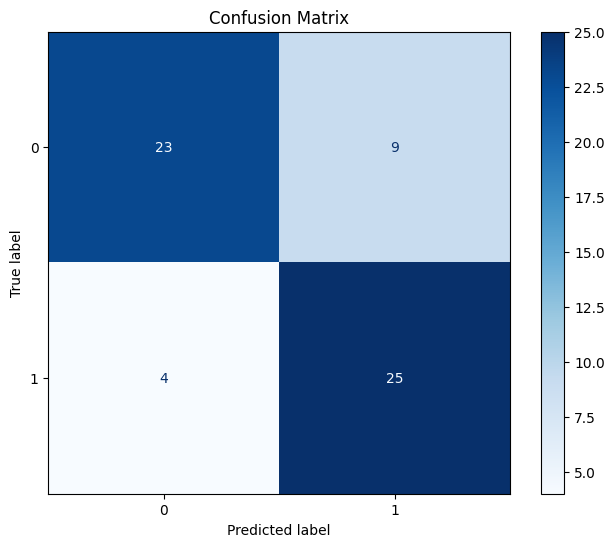

In [ ]:
# Display the confusion matrix visually
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_classifier.classes_).plot(cmap='Blues', ax=plt.gca())
plt.title('Confusion Matrix')
plt.show()

This confusion matrix visualizes the performance of the initial SVM model, showing true positives, true negatives, false positives, and false negatives.

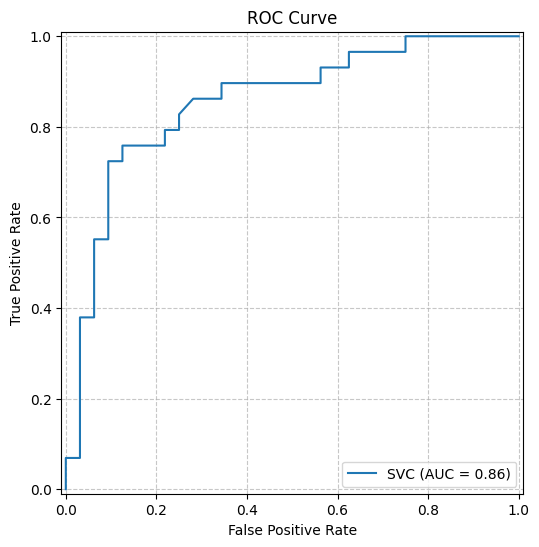

In [ ]:
# Plot the ROC curve
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(svm_classifier, X_test, y_test, name='SVC', ax=plt.gca())
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The ROC curve plots the true positive rate against the false positive rate, illustrating the classifier's performance at various threshold settings.

### **Train vs Test Score Check:**

In [ ]:
# Calculate training accuracy
y_train_pred = svm_classifier.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Display training and testing accuracy for comparison
display(f"Training Accuracy: {train_accuracy:.4f}")
display(f"Testing Accuracy: {accuracy:.4f}")

'Training Accuracy: 0.9129'

'Testing Accuracy: 0.7869'

### **Hyperparameter Tuning (GridSearchCV):**

In [ ]:
# Define the parameter grid for SVC
# We will tune 'C' (regularization parameter), 'kernel', and 'gamma' (kernel coefficient for 'rbf', 'poly', 'sigmoid')
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.1, 1]
}

# Initialize GridSearchCV with the SVC model
# svm_classifier is already initialized from cell `ae1b2a60` with probability=True and random_state=42
# cv=5 for 5-fold cross-validation, scoring='accuracy' for the evaluation metric
grid_search = GridSearchCV(estimator=svm_classifier, param_grid=param_grid, cv=5, scoring='accuracy', verbose=0)

# Display the GridSearchCV object to confirm initialization
display(grid_search)

GridSearchCV(cv=5, estimator=SVC(probability=True, random_state=42),
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 'auto', 0.1, 1],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [ ]:
# Fit GridSearchCV on the scaled training data
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(probability=True, random_state=42),
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 'auto', 0.1, 1],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [ ]:
# Display the best parameters found by GridSearchCV
display(f"Best Parameters: {grid_search.best_params_}")

# Display the best cross-validation score achieved with these parameters
display(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

"Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}"

'Best Cross-Validation Accuracy: 0.8214'

In [ ]:
best_svm_model = grid_search.best_estimator_

In [ ]:
# Make predictions on the scaled test data using the best model
y_pred_tuned = best_svm_model.predict(X_test)
y_pred_proba_tuned = best_svm_model.predict_proba(X_test)[:, 1]

In [ ]:
# Calculate evaluation metrics for the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned)

# Display the tuned model's performance metrics
display("--- Tuned SVM Model Performance ---")
display(f"Tuned Accuracy: {accuracy_tuned:.4f}")
display(f"Tuned Precision: {precision_tuned:.4f}")
display(f"Tuned Recall: {recall_tuned:.4f}")
display(f"Tuned F1 Score: {f1_tuned:.4f}")
display(f"Tuned AUC Score: {roc_auc_tuned:.4f}")

'--- Tuned SVM Model Performance ---'

'Tuned Accuracy: 0.7705'

'Tuned Precision: 0.7273'

'Tuned Recall: 0.8276'

'Tuned F1 Score: 0.7742'

'Tuned AUC Score: 0.8524'

In [ ]:
# Calculate training accuracy for the tuned model
y_train_pred_tuned = best_svm_model.predict(X_train)
train_accuracy_tuned = accuracy_score(y_train, y_train_pred_tuned)

# Display training and testing accuracy for comparison for the tuned model
display(f"Tuned Training Accuracy: {train_accuracy_tuned:.4f}")
display(f"Tuned Testing Accuracy: {accuracy_tuned:.4f}")

'Tuned Training Accuracy: 0.8714'

'Tuned Testing Accuracy: 0.7705'

In [ ]:
# Display the confusion matrix for the tuned model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
display(cm_tuned)

array([[23,  9],
       [ 5, 24]])

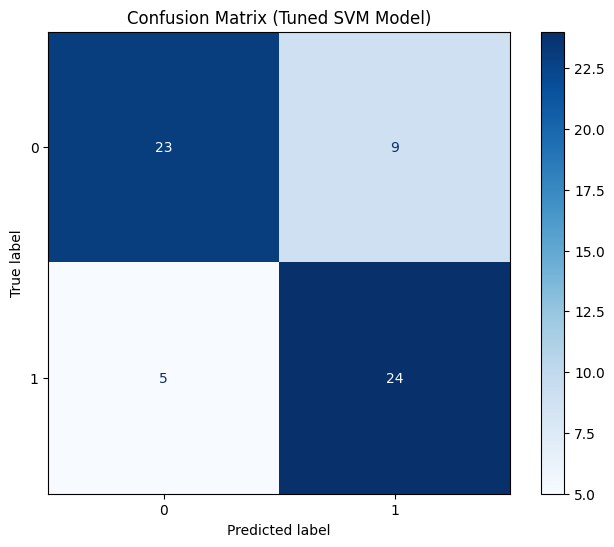

In [ ]:
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=best_svm_model.classes_).plot(cmap='Blues', ax=plt.gca())
plt.title('Confusion Matrix (Tuned SVM Model)')
plt.show()

This confusion matrix visualizes the performance of the tuned SVM model after hyperparameter optimization.

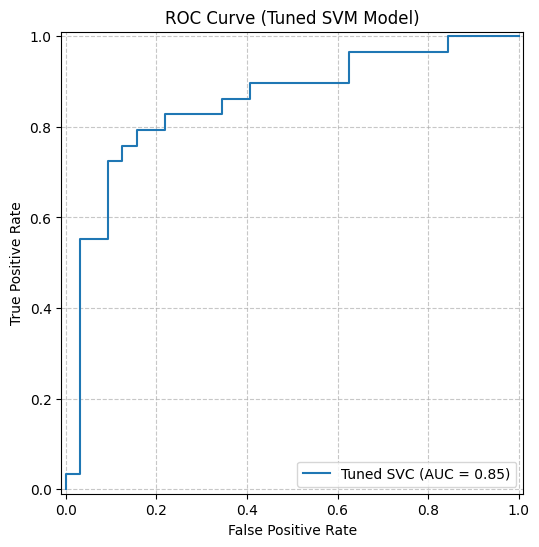

In [ ]:
# Plot the ROC curve for the tuned model
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(best_svm_model, X_test, y_test, name='Tuned SVC', ax=plt.gca())
plt.title('ROC Curve (Tuned SVM Model)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The ROC curve for the tuned SVM model shows its improved classification performance.

### **Cross-Validation:**

In [ ]:
cv_scores = cross_val_score(best_svm_model, X, y, cv=5, scoring='accuracy', n_jobs=-1)

print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean CV accuracy score: {cv_scores.mean():.4f}")

Cross-validation accuracy scores: [0.83606557 0.83606557 0.91666667 0.76666667 0.76666667]
Mean CV accuracy score: 0.8244


### **Pipeline (final packaging):**

In [ ]:
# Instantiate a new scaler for the pipeline (to be fit within the pipeline)
scaler_pipeline = StandardScaler()

# Define the pipeline with the scaler and the best_svm_model
final_pipeline = Pipeline([
    ('scaler', scaler_pipeline),
    ('svm', best_svm_model)
])

In [ ]:
# Fit the final pipeline on the original (unscaled) training data
# This ensures the scaler learns from the full training set and transforms it before SVM training.
final_pipeline.fit(X_train.copy(), y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm',
                 SVC(C=0.1, kernel='linear', probability=True,
                     random_state=42))])

In [ ]:
# Evaluate the final pipeline on the original (unscaled) test data
y_pred_pipeline = final_pipeline.predict(X_test.copy())
y_pred_proba_pipeline = final_pipeline.predict_proba(X_test.copy())[:, 1]

In [ ]:
accuracy_pipeline = accuracy_score(y_test, y_pred_pipeline)
precision_pipeline = precision_score(y_test, y_pred_pipeline)
recall_pipeline = recall_score(y_test, y_pred_pipeline)
f1_pipeline = f1_score(y_test, y_pred_pipeline)
roc_auc_pipeline = roc_auc_score(y_test, y_pred_proba_pipeline)


display(f"Pipeline Accuracy: {accuracy_pipeline:.4f}")
display(f"Pipeline Precision: {precision_pipeline:.4f}")
display(f"Pipeline Recall: {recall_pipeline:.4f}")
display(f"Pipeline F1 Score: {f1_pipeline:.4f}")
display(f"Pipeline AUC Score: {roc_auc_pipeline:.4f}")

'Pipeline Accuracy: 0.8033'

'Pipeline Precision: 0.7429'

'Pipeline Recall: 0.8966'

'Pipeline F1 Score: 0.8125'

'Pipeline AUC Score: 0.8707'

### **Final Output:**

In [ ]:
final_metrics_df = pd.DataFrame({
    'Metric': ['Pipeline Accuracy'],
    'Value': [accuracy_pipeline]
})
display(final_metrics_df)

,Metric,Value
0,Pipeline Accuracy,0.803279


### **Conclusion:**
*   The dataset was successfully loaded, cleaned (duplicates removed, outliers capped), and preprocessed (categorical features encoded, numerical features scaled).
*   An SVC model was trained and evaluated, demonstrating reasonable performance, which was further improved through hyperparameter tuning with GridSearchCV.
*   The final pipeline integrates scaling and the best-performing SVM model, providing a robust solution for heart disease prediction.